In [1]:
import pandas as pd
df = pd.read_csv('online_retail.csv')
print(df.head())
print(df.shape)
print(df.columns)


  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

           InvoiceDate  UnitPrice  CustomerID         Country  
0  2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2  2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
(541909, 8)
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')


In [2]:
print(df.info())



<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB
None


In [3]:
print(df.describe())
print(df.isnull().sum())

            Quantity      UnitPrice     CustomerID
count  541909.000000  541909.000000  406829.000000
mean        9.552250       4.611114   15287.690570
std       218.081158      96.759853    1713.600303
min    -80995.000000  -11062.060000   12346.000000
25%         1.000000       1.250000   13953.000000
50%         3.000000       2.080000   15152.000000
75%        10.000000       4.130000   16791.000000
max     80995.000000   38970.000000   18287.000000
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [4]:
df['CustomerID'].nunique()

4372

In [5]:
df['Country'].nunique()

38

In [6]:
df['Country'].value_counts().head(10)

Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64

In [7]:
# min/max of Quantity and UnitPrice
print(df['Quantity'].describe())
print(df['UnitPrice'].describe())

count    541909.000000
mean          9.552250
std         218.081158
min      -80995.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: Quantity, dtype: float64
count    541909.000000
mean          4.611114
std          96.759853
min      -11062.060000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: UnitPrice, dtype: float64


In [8]:
# 1. drop missing CustomerID
df.dropna(subset=['CustomerID'], inplace=True)

# 2. remove cancellations
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# 3. remove bad quantity and price rows
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

# 4. convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 5. create TotalPrice column
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# confirm what's left
print(df.shape)

(397884, 9)


In [9]:
# reference date
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Recency
recency = df.groupby('CustomerID')['InvoiceDate'].max()
recency = (reference_date - recency).dt.days

# Frequency
frequency = df.groupby('CustomerID')['InvoiceNo'].nunique()

# Monetary
monetary = df.groupby('CustomerID')['TotalPrice'].sum()

# combine
rfm = pd.DataFrame({'Recency': recency, 'Frequency': frequency, 'Monetary': monetary})
print(rfm.shape)
print(rfm.head())

(4338, 3)
            Recency  Frequency  Monetary
CustomerID                              
12346.0         326          1  77183.60
12347.0           2          7   4310.00
12348.0          75          4   1797.24
12349.0          19          1   1757.55
12350.0         310          1    334.40


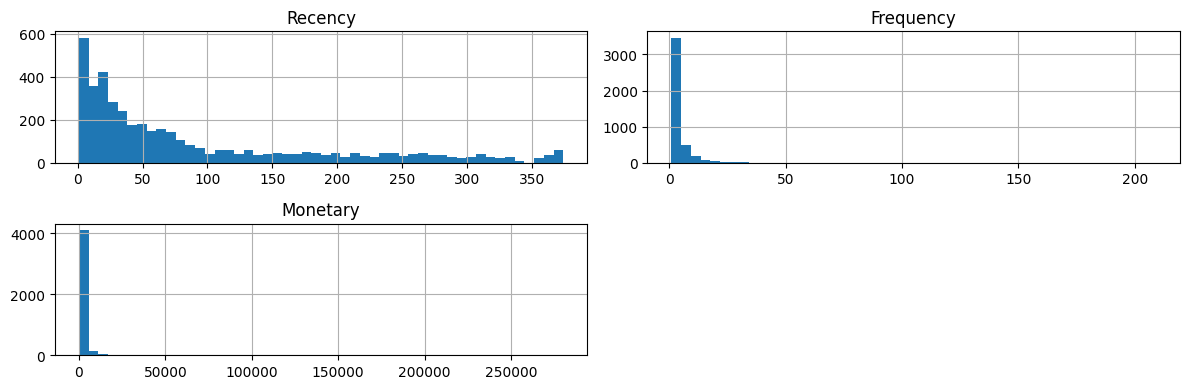

In [10]:
import matplotlib.pyplot as plt

rfm.hist(bins=50, figsize=(12, 4))
plt.tight_layout()
plt.show()

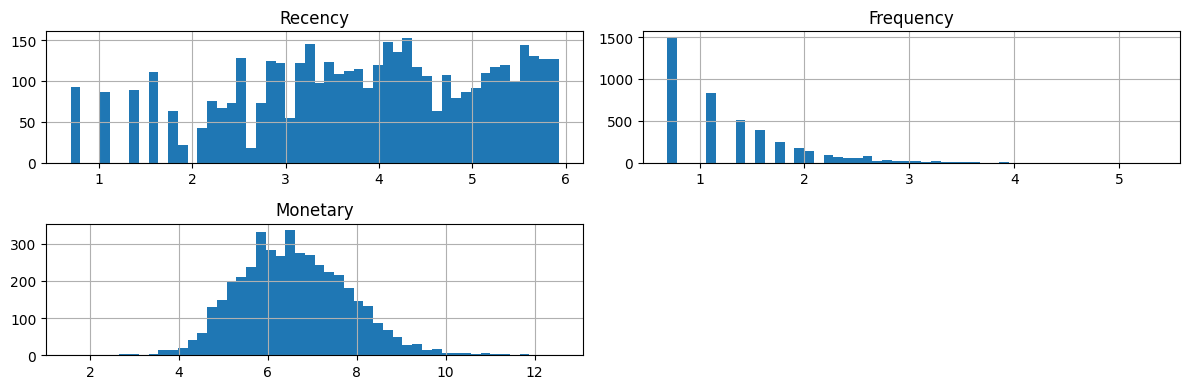

In [11]:
#we do this rfm log for easier customer segmentation and to handle skewness in the data
import numpy as np

rfm_log = rfm.copy()
rfm_log['Recency'] = np.log1p(rfm['Recency'])
rfm_log['Frequency'] = np.log1p(rfm['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm['Monetary'])

rfm_log.hist(bins=50, figsize=(12, 4))
plt.tight_layout()
plt.show()

In [12]:
#we do this for better performance of the model and to make sure that all features are on the same scale
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm_log)

print(X_scaled.shape)

(4338, 3)


# Elbow Method — K-Means

## What is K-Means trying to do?
Group 4338 customers into **K groups** where customers inside the same group are as similar as possible to each other.

But you need to tell K-Means how many groups — that's **K**.  
You don't know if K=3 or K=5 or K=7 is best. That's the problem elbow method solves.

---

## What is Inertia?
When K-Means forms clusters, each cluster has a **center point**.

> **Inertia = sum of distances of every customer from their cluster center**

- Lower inertia = customers are closer to their center = tighter, better clusters

---

## Why Not Just Pick the Highest K?

If K = 4338 → every customer is their own cluster → inertia = 0.  
Useless. You want **meaningful groups**, not one group per person.

---

## What the Elbow Method Does

Run K-Means for K = 1, 2, 3 ... 10. Plot inertia for each K:

```
K=1  →  inertia very high  (everyone in one group, very spread)
K=2  →  drops a lot
K=3  →  drops a lot
K=4  →  drops a little
K=5  →  barely drops
K=6  →  barely drops
```

> The point where the drop **suddenly becomes small** = the elbow = best K  
> After that point, adding more clusters gives almost no improvement

---

## Why is it Called Elbow?

Because the graph literally looks like an arm —  
**steep drop → bends → flattens out**  
The bend = the elbow.



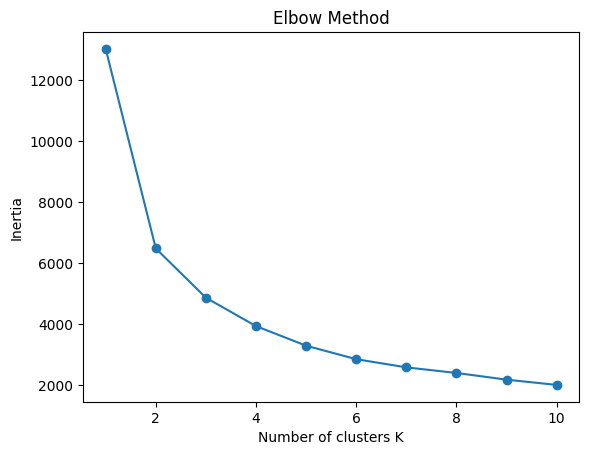

In [13]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of clusters K')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [14]:
#silhouette score is for evaluating the quality of clusters. It ranges from -1 to 1, where a higher score indicates better-defined clusters. A score close to 1 means that the samples are well clustered, while a score close to -1 indicates that the samples may have been assigned to the wrong cluster.
# it works by measuring how similar a sample is to its own cluster compared to other clusters. A higher silhouette score indicates that the sample is well matched to its own cluster and poorly matched to neighboring clusters, which suggests that the clustering is appropriate for the data.
from sklearn.metrics import silhouette_score

sil_scores = []
K_range = range(2, 8)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)
    print(f"K={k} → Silhouette Score: {score:.4f}")

K=2 → Silhouette Score: 0.4332
K=3 → Silhouette Score: 0.3360
K=4 → Silhouette Score: 0.3371
K=5 → Silhouette Score: 0.3173
K=6 → Silhouette Score: 0.3143
K=7 → Silhouette Score: 0.2875


In [15]:
#k=4 is better than k=2 even thoug less silhouette score but it is more interpretable and actionable for business decisions. With k=4,


#below code is for assigning cluster labels to the original rfm dataframe and then analyzing the clusters by looking at their mean values for each feature. This helps us understand the characteristics of each cluster and how they differ from each other, which can be useful for making business decisions based on customer segmentation.
km = KMeans(n_clusters=4, init='k-means++', random_state=42)
rfm['Cluster'] = km.fit_predict(X_scaled)

print(rfm['Cluster'].value_counts())
print()
print(rfm.groupby('Cluster').mean())

Cluster
3    1612
2    1173
0     837
1     716
Name: count, dtype: int64

            Recency  Frequency     Monetary
Cluster                                    
0         18.124253   2.148148   551.819534
1         12.131285  13.713687  8074.266872
2         71.084399   4.083546  1802.829005
3        182.496898   1.318238   343.450032


## Cluster Interpretation

| Cluster | Recency | Frequency | Monetary | Label |
|---------|---------|-----------|----------|-------|
| 0       | 18 days | 2 orders  | £551     | New Customers |
| 1       | 12 days | 13 orders | £8074    | Champions |
| 2       | 71 days | 4 orders  | £1802    | Regular Customers |
| 3       | 182 days| 1 order   | £343     | Lost Customers |

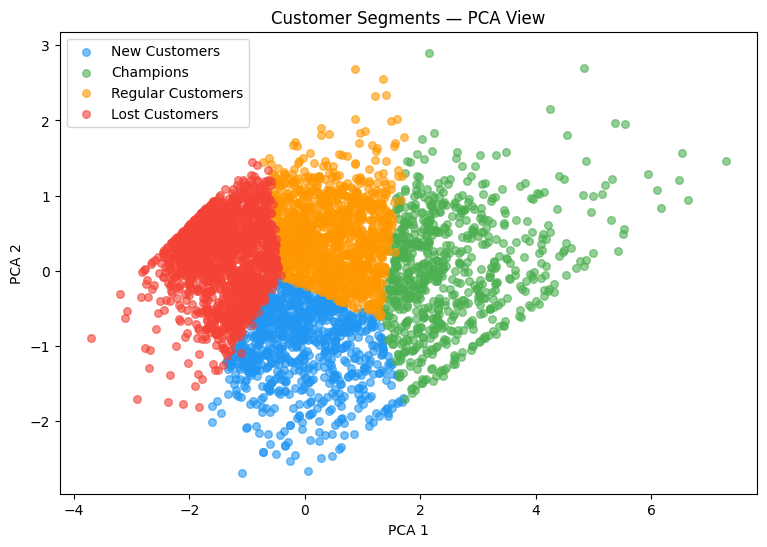

In [16]:
#below code is for visualizing the clusters in 2D space using PCA (Principal Component Analysis). PCA is a dimensionality reduction technique that helps us visualize high-dimensional data by projecting it onto a lower-dimensional space while preserving as much variance as possible. In this case, we reduce our 3D RFM data to 2D for easier visualization of the customer segments. 

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_coords = pca.fit_transform(X_scaled)

plt.figure(figsize=(9, 6))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']
labels = ['New Customers', 'Champions', 'Regular Customers', 'Lost Customers']

for i in range(4):
    mask = rfm['Cluster'] == i
    plt.scatter(pca_coords[mask, 0], pca_coords[mask, 1],
                c=colors[i], label=labels[i], alpha=0.6, s=30)

plt.title('Customer Segments — PCA View')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.show()

In [17]:
#now lets go to anomly detection using isolation forest
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.05, random_state=42)
rfm['Anomaly'] = iso.fit_predict(X_scaled)

# -1 = anomaly, 1 = normal
print(rfm['Anomaly'].value_counts())
print()
print(rfm[rfm['Anomaly'] == -1][['Recency', 'Frequency', 'Monetary']].describe())

Anomaly
 1    4121
-1     217
Name: count, dtype: int64

          Recency   Frequency       Monetary
count  217.000000  217.000000     217.000000
mean    52.912442   20.894009   18140.868525
std     97.671533   26.288513   36122.763251
min      1.000000    1.000000       3.750000
25%      1.000000    3.000000    1653.420000
50%      4.000000   16.000000    7832.470000
75%     39.000000   27.000000   16587.090000
max    373.000000  209.000000  280206.020000


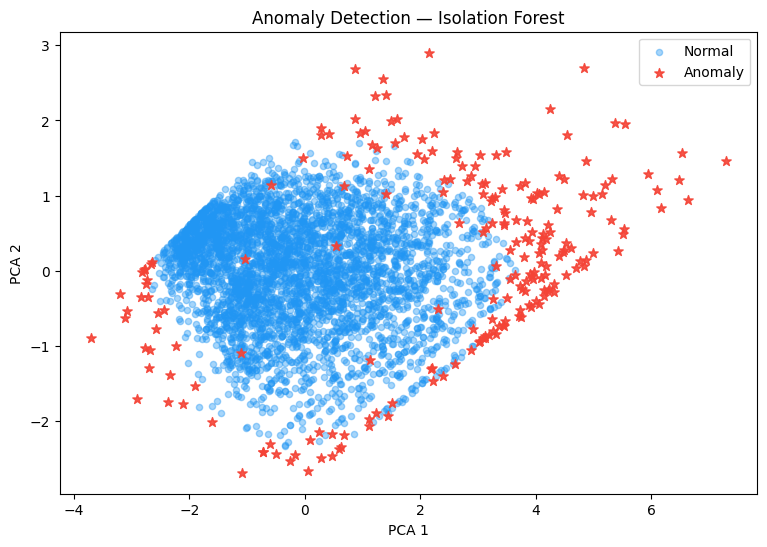

In [ ]:
plt.figure(figsize=(9, 6))

normal = rfm['Anomaly'] == 1
anomaly = rfm['Anomaly'] == -1

plt.scatter(pca_coords[normal, 0], pca_coords[normal, 1],
            c='#2196F3', label='Normal', alpha=0.4, s=20)
plt.scatter(pca_coords[anomaly, 0], pca_coords[anomaly, 1],
            c='#F44336', label='Anomaly', alpha=0.9, s=50, marker='*')

plt.title('Anomaly Detection — Isolation Forest')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.show()
#the fig has red dots insdie blue also b

## Anomaly Detection — Isolation Forest Plot Interpretation

- Blue dots = 4121 normal customers — dense cluster in the center
- Red stars = 217 anomalous customers (5% of 4338) — scattered around the edges

**What the positions mean:**

- Red stars far right → extreme Champions — customers who ordered 200+ times 
  and spent up to £280,000. So different from everyone they got pushed far right by PCA.

- Red stars far left → extreme Lost customers — unusually high recency combined 
  with near-zero frequency and very low monetary. Opposite extreme.

- Red stars inside the blue cloud → the 153 anomalies Z-score missed completely.
  These customers are not extreme on any single feature but their combination of 
  Recency, Frequency and Monetary together is unusual. PCA flattened 3D to 2D 
  so they look normal here — but in the original RFM space they are outliers.

**Key takeaway:**
Isolation Forest detects anomalies in all 3 dimensions simultaneously.
Z-score only caught 64 of these 217 — the obvious single-feature extremes.
The remaining 153 are invisible to Z-score but real anomalies in RFM space.

In [19]:
from scipy import stats

# calculate z-scores on original rfm (not log transformed)
z_scores = np.abs(stats.zscore(rfm[['Recency', 'Frequency', 'Monetary']]))

# flag as anomaly if any feature has |Z| > 3
rfm['Zscore_Anomaly'] = (z_scores > 3).any(axis=1)

print("Z-score anomalies found:", rfm['Zscore_Anomaly'].sum())
print()

# compare — same customers or different?
iso_anomalies = set(rfm[rfm['Anomaly'] == -1].index)
z_anomalies = set(rfm[rfm['Zscore_Anomaly'] == True].index)

print("Both methods caught:", len(iso_anomalies & z_anomalies))
print("Only Isolation Forest caught:", len(iso_anomalies - z_anomalies))
print("Only Z-score caught:", len(z_anomalies - iso_anomalies))

Z-score anomalies found: 64

Both methods caught: 64
Only Isolation Forest caught: 153
Only Z-score caught: 0


## Anomaly Detection — Method Comparison

| Method           | Anomalies Found | Unique to it |
|------------------|-----------------|--------------|
| Isolation Forest | 217             | 153          |
| Z-score   | 64              | 0            |
| Both caught      | 64              | —            |

Z-score only catches single-feature extremes (one column > 3 std away).
Isolation Forest catches multi-dimensional anomalies — customers who are 
unusual in the combination of Recency, Frequency and Monetary together.
For RFM data, Isolation Forest is the better choice.

## Project Summary

### Dataset
Online Retail UCI — 541,909 raw transactions
After cleaning → 397,884 rows → 4,338 unique customers

### What was built
1. Data cleaning — removed cancellations, missing CustomerIDs, bad quantities and prices
2. RFM feature engineering — converted raw transactions into customer-level features
3. Log transform + StandardScaler — fixed skew and scaled before clustering
4. K-Means clustering (K=4) — found using elbow method + silhouette score
5. Isolation Forest — anomaly detection on RFM space

### Customer Segments Found
| Cluster | Label | Customers | Avg Recency | Avg Frequency | Avg Monetary |
|---------|-------|-----------|-------------|---------------|--------------|
| 0 | New Customers | 837 | 18 days | 2 orders | £551 |
| 1 | Champions | 716 | 12 days | 13 orders | £8074 |
| 2 | Regular Customers | 1173 | 71 days | 4 orders | £1802 |
| 3 | Lost Customers | 1612 | 182 days | 1 order | £343 |

### Anomaly Detection
- Isolation Forest flagged 217 anomalous customers (5%)
- Z-score only caught 64 — missed 153 that Isolation Forest found
- Anomalies are mostly extreme bulk buyers and wholesale accounts

### Concepts learned
- Unsupervised learning — no labels, model finds patterns itself
- RFM engineering — summarizing customer behavior into 3 numbers
- Why skew matters for distance-based algorithms
- Elbow method + silhouette score to pick K
- Isolation Forest vs Z-score for anomaly detection
- PCA for visualizing high dimensional clusters in 2D